In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from scipy.stats import lognorm
from scipy.optimize import curve_fit

In [5]:
def distrib_log(x, s, loc,scale ,amp ,base):
    '''

    :param x: Time array
    :param s: shape parameter
    :param loc: location parameter
    :param scale: scale parameter
    :param amp: amplitude factor of the lognormal
    :param base: baseline value of the of the cumulative function
    :return: log normal cumulative function
    '''
    return amp*lognorm.cdf(x, s, loc=loc, scale=scale) + base

In [6]:
# Define Plotting style
mpl.rcParams['lines.linewidth'] = 2

In [17]:
folder_processed_data = 'Processed_data/BEOIC'

In [39]:
melt_rate = 3.5/60 #IGE : 3.8

##### BE-OIC User's parameters

In [295]:
# You first need to extract from a SARA AvC file the section of interest with the STEP you want to process
folder_name = '20260225'
file_name = '20260225_step_STD1-STD2_shortSSline_cleaned.txt'

In [441]:
file_cfa = '/home/fainx/projects/CFA-data-processing/CFA_transfer_function/Raw_data/'+ folder_name+'/'+ file_name
file_cfa 

'/home/fainx/projects/CFA-data-processing/CFA_transfer_function/Raw_data/20260226/20260226_step_STD1-STD2_shortSSline_cleaned.txt'

In [442]:
data = np.loadtxt(file_cfa,skiprows=1)
time_raw= data[:,0]
ch4 = data[:,1]
co = data[:,3]
# Interpolate time and methane on a regular grid
time_min, time_max, dt = time_raw[0], time_raw[-1], np.nanmean(np.diff(time_raw))
#dt = 1/24/3600

N = int((time_max-time_min)/dt)
time = np.linspace(time_min,time_max,num=N)
ch4 = np.interp(time,time_raw,ch4)
co = np.interp(time,time_raw,co)

# Convert time in seconds
time = (time - time[0]) * 3600 * 24
dt *= 3600 *24

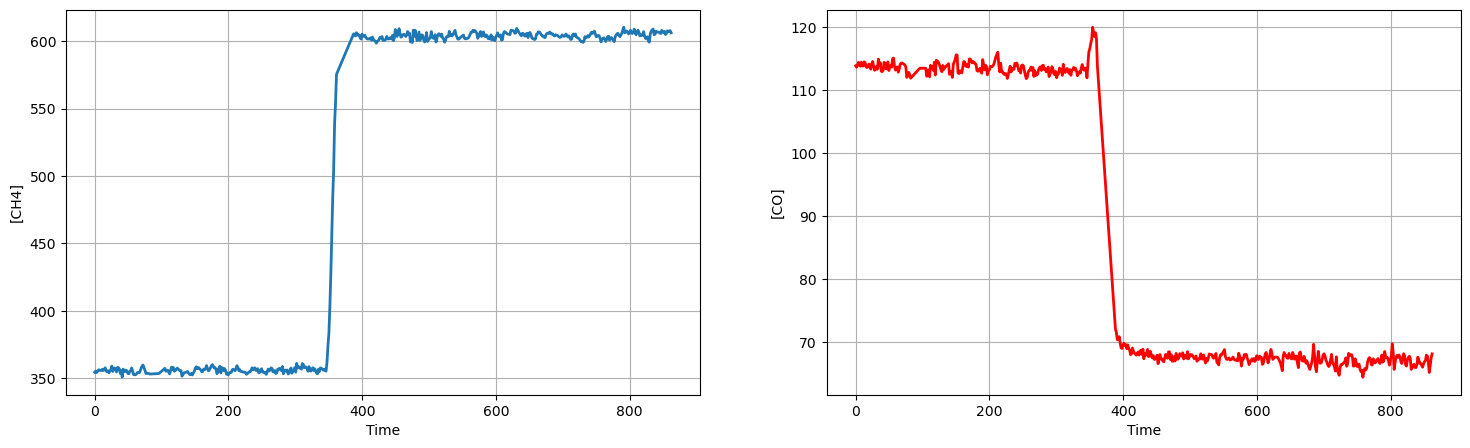

In [443]:
# Plot input CH4 and CO data 

fig = plt.figure(figsize=(18, 5), facecolor='white')

ax1 = plt.subplot(1, 2, 1)
ax1.plot(time, ch4)
ax1.set_xlabel("Time")
ax1.set_ylabel("[CH4]")
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(time, co, color='red')
ax2.set_xlabel("Time")
ax2.set_ylabel("[CO]")
ax2.grid(True)

plt.show()

In [444]:
# Initial guess to help optimization
base = 5
amp = 160
loc = 250

In [445]:
# Fit function to data
popt, pcov = curve_fit(distrib_log,time,ch4,p0=[1, loc, 100, amp, base])

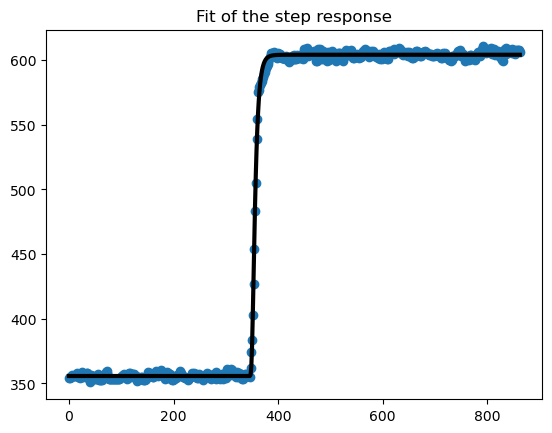

In [446]:
# Plot the Fit
plt.scatter(time,ch4)
plt.plot(time,distrib_log(time,*popt),color='black',linewidth=3)
plt.title('Fit of the step response')
plt.show()

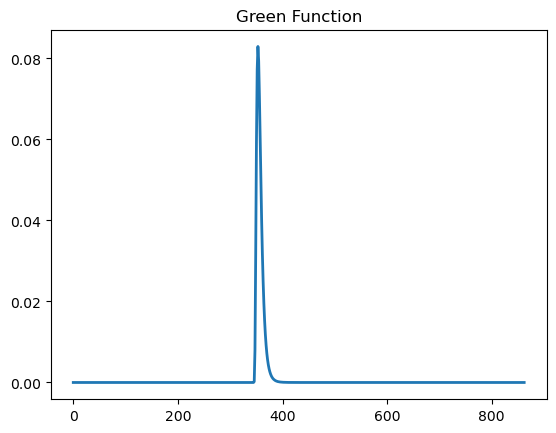

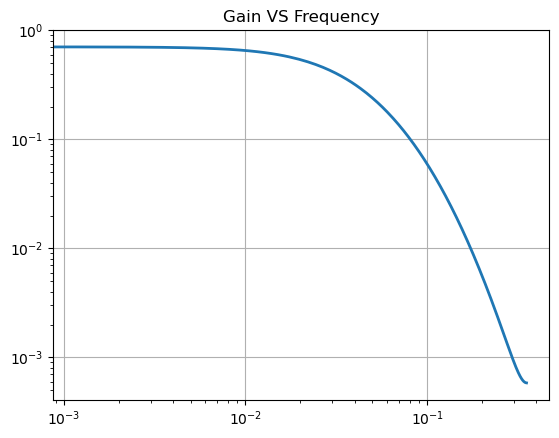

In [447]:
# Save parameters
shape = popt[0]
loc = popt[1]
scale = popt[2]
amp = popt[3]
base = popt[4]

# Get Green Function
Green_Func = lognorm.pdf(time,shape,loc=loc,scale=scale)
plt.plot(time,Green_Func)
plt.title('Green Function')
plt.show()

# Get Fourier transform and Plot as Bode diagram
fourier = np.fft.rfft(Green_Func)
N = Green_Func.size
freq = np.fft.rfftfreq(N, d=dt)
plt.loglog(freq, np.abs(fourier))
plt.grid(True)
plt.title('Gain VS Frequency')
plt.show()

/tmp/ipykernel_966/2497666462.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(time,ch4, c=(249/255.,189/255.,53/255.),s=40)
/tmp/ipykernel_966/2497666462.py:36: RuntimeWarning: divide by zero encountered in divide
  ax3.loglog(melt_rate/freq, np.abs(fourier))


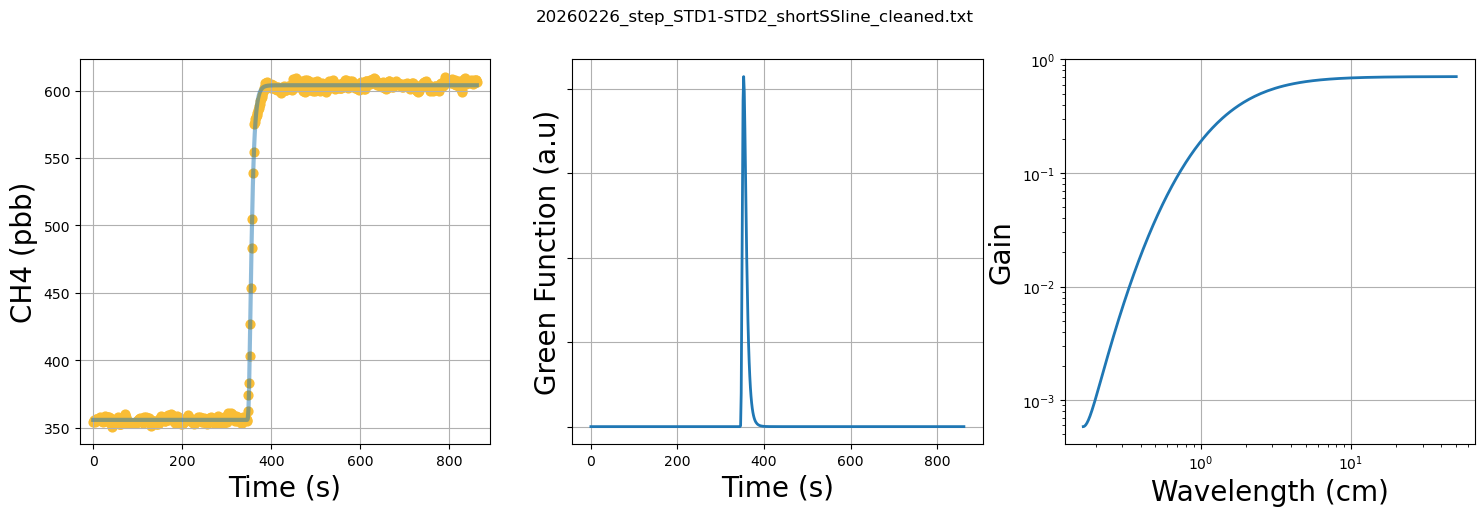

In [448]:
# Make a plot with depth scale rather than time scale

fig = plt.figure(figsize=(18, 5), facecolor='white')
ax1 = plt.subplot(1, 3, 1)
ax1.plot(time,distrib_log(time,*popt),linewidth=3, alpha=.5)
ax1.scatter(time,ch4, c=(249/255.,189/255.,53/255.),s=40)
ax1.set_xlabel('Time (s)', fontsize=20)
ax1.set_ylabel('CH4 (pbb)', fontsize=20)
# ax1.set_xlim([-30,1780])
ax1.set_xlim([-30,time.max()+30])
#ax1.set_ylim([0,300])
ax1.set_facecolor('white')
plt.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(time,Green_Func)
ax2.set_xlabel('Time (s)', fontsize=20)
ax2.set_ylabel('Green Function (a.u)', fontsize=20)
plt.setp(ax2.get_yticklabels(), visible=False)
ax2.set_facecolor('white')
plt.grid(True)

ax3 = plt.subplot(1, 3, 3)
ax3.loglog(melt_rate/freq, np.abs(fourier))
ax3.set_xlabel('Wavelength (cm)', fontsize=20)
ax3.set_ylabel('Gain', fontsize=20)
#ax3.set_ylim([0.49,0.51])
ax3.set_facecolor('white')
plt.grid(True)

fig.suptitle(file_name)

figure_name = folder_processed_data+'/'+file_name+'_fig.png'
plt.savefig(figure_name)

plt.show()   

In [450]:
# Save results
file_save = file_name + '_Green_Function_CFA.txt'
np.savetxt(folder_processed_data+'/'+file_save,np.column_stack(((melt_rate/freq, np.abs(fourier)))))

/tmp/ipykernel_966/2714064635.py:3: RuntimeWarning: divide by zero encountered in divide
  np.savetxt(folder_processed_data+'/'+file_save,np.column_stack(((melt_rate/freq, np.abs(fourier)))))
